In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [20, 10]
import pandas as pd
%matplotlib inline

# Purpose

Since we found out that LSTM RNN with min-max normalization performs the best in this scenario, this notebook tests the performance of the LSTM RNN model (using min-max normalization) on two intensive training tasks. Both training tasks involve utilizing all of the stations' data (we use all 6 stations' merged soil and met datasets).

## Task 1
Task 1 involves training the LSTM RNN model in such a way by splitting the dataset into train, validation, and test sets like this:

*2015-2020 all stations (training data), 2021 (validation data [every station except station 3]), Station 3 2021 (testing data)*

## Task 2
Do a non-nested cross-validation loop to train LSTM RNN model over all the stations. The CV Loop architecture is as follows: 6 training years and 1 testing year.
- CV Loop is 7-fold and trains the 6 training years against the 1 testing dataset in each iteration
- after each iteration, an accuracy and loss is obtained
- datasets change each iteration in a sliding window fashion (as demonstrated in the image below)
  - each iteration of the training is done on a new instance of the LSTM RNN model to prevent testing on training data
- as a result, we get 5 LSTM RNN models with 5 accuracies and losses -> average the losses of all 5 models to provide the LSTM RNN model's performance on this dataset


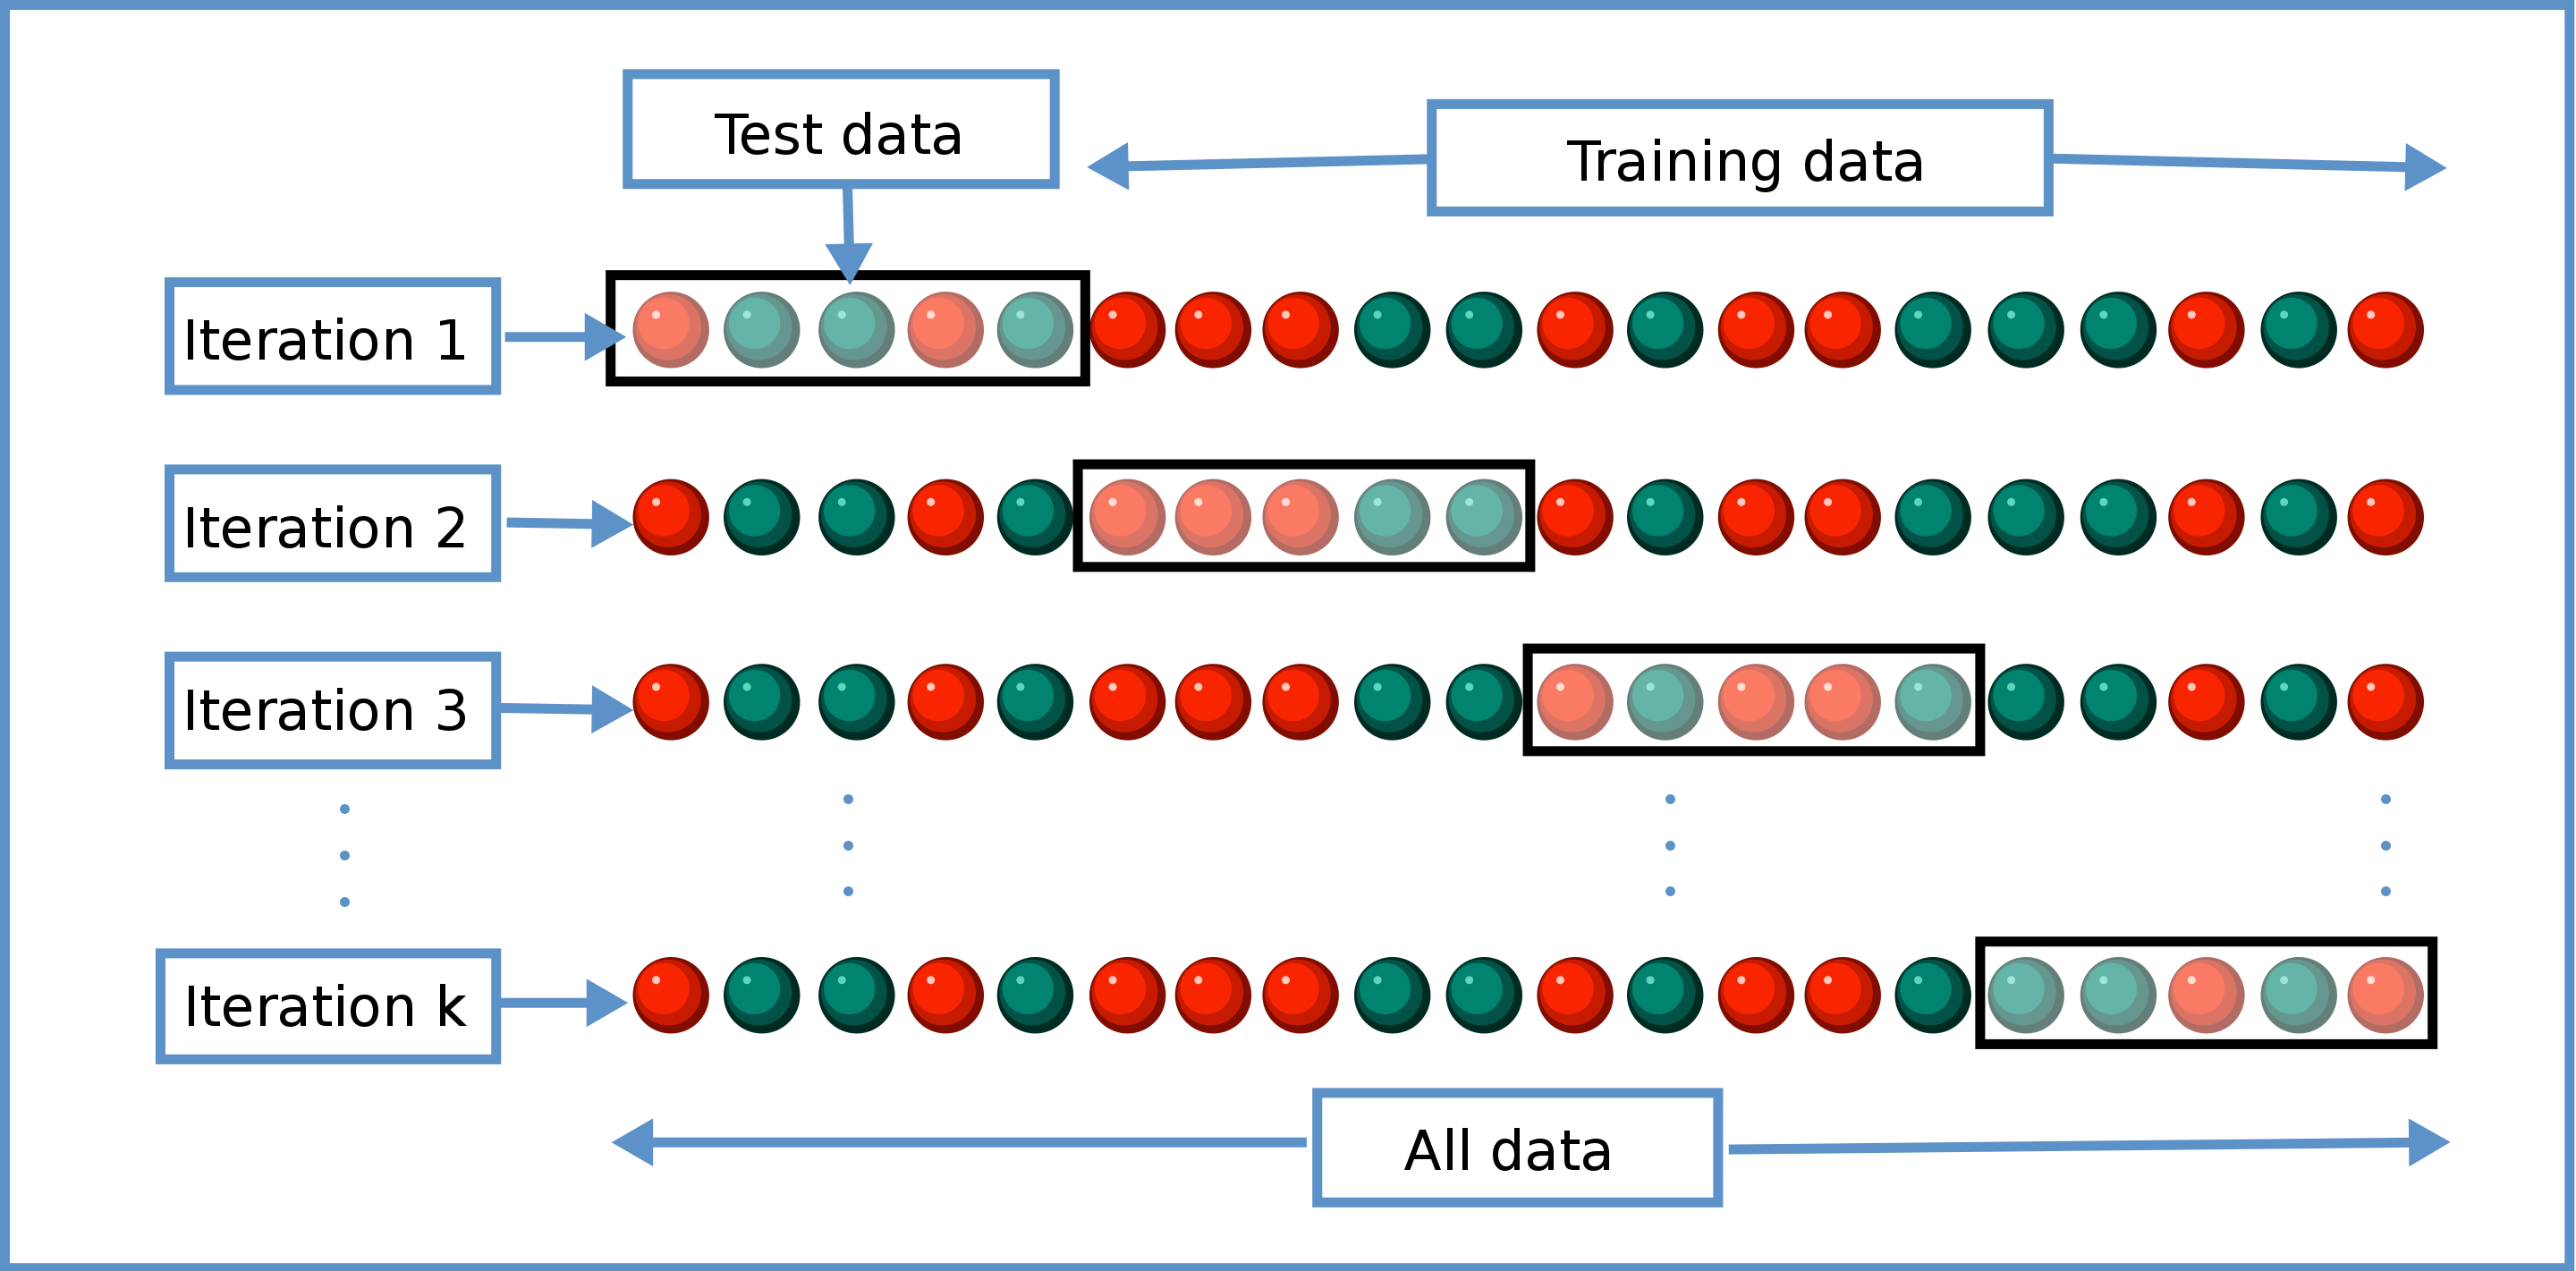

Task 2 NOTE: I am not using validation set as this is a non-nested CV loop (as per the requirements of this task). Since
my goal is to not tune hyperparameters of the model in this task, not having validation data should be alright for this use case.

Additionally, as seen in the upcoming cell, I set MAX_EPOCHS to 7 epochs down from the previous 100 epochs. MAX_EPOCHS is 7 because keras early stopping, when monitoring loss, is not meaningful and will train unecessarily long. I can't monitor early stopping using val_loss (as I have done in the past) because this training has no validation data

# Params Used
Epochs = 100

Learning Rate = 0.001

Dataset = All Stations' Merged (soil + met) datasets

Prediction period = 7 days

# Task 1 Results

In [2]:
df_loss = pd.read_csv('task1-results.csv', sep=",", index_col="Depth")
df_loss

,Loss,Mean_absolute_error,Val_loss,Val_mean_absolute_error
Depth,,,,
5cm,0.000061,0.0026,0.000149,0.0040
10cm,0.000043,0.0022,0.000114,0.0032
20cm,0.000017,0.0016,0.000104,0.0030
50cm,0.000009,0.0012,0.000047,0.0011


Looking purely at the numbers, this model performed extremely well across the board, with really low values for all attriibutes for all soil depths. The model's performance on the 50 cm depth was most remarkable, as it had values for all four training attributes that stood out from the other depths.

# Model Accuracy Visualizations

For each soil depth, two visualization will follow:

- A visualization of how well the model performed on 3 random examples from the test set
- A visualization of how well the model performed on when predicting on the entire test set

## 5 cm

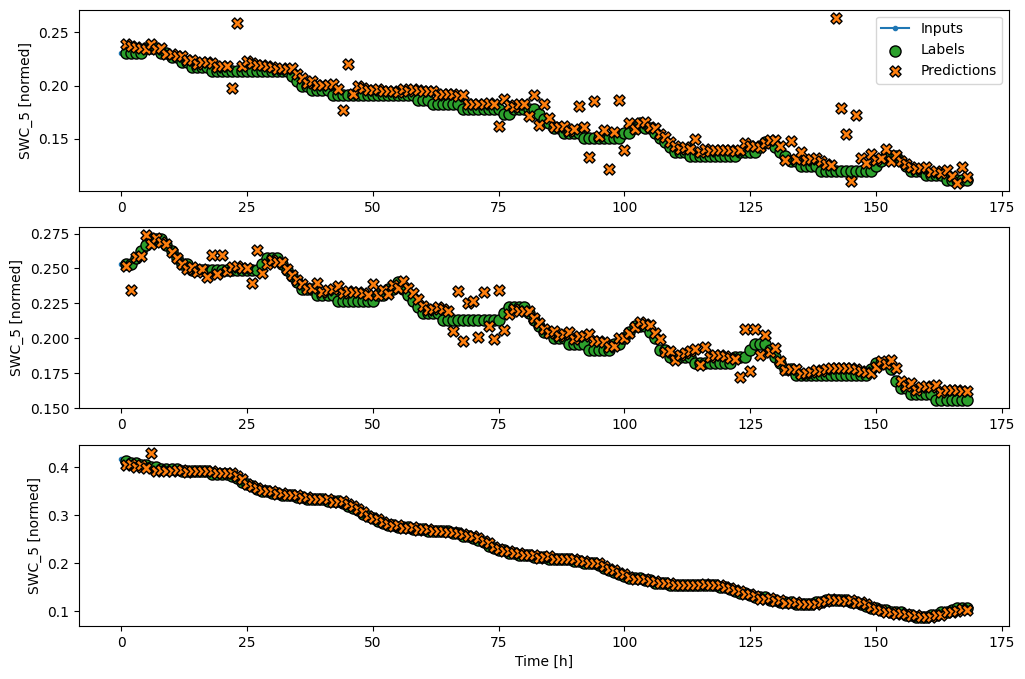

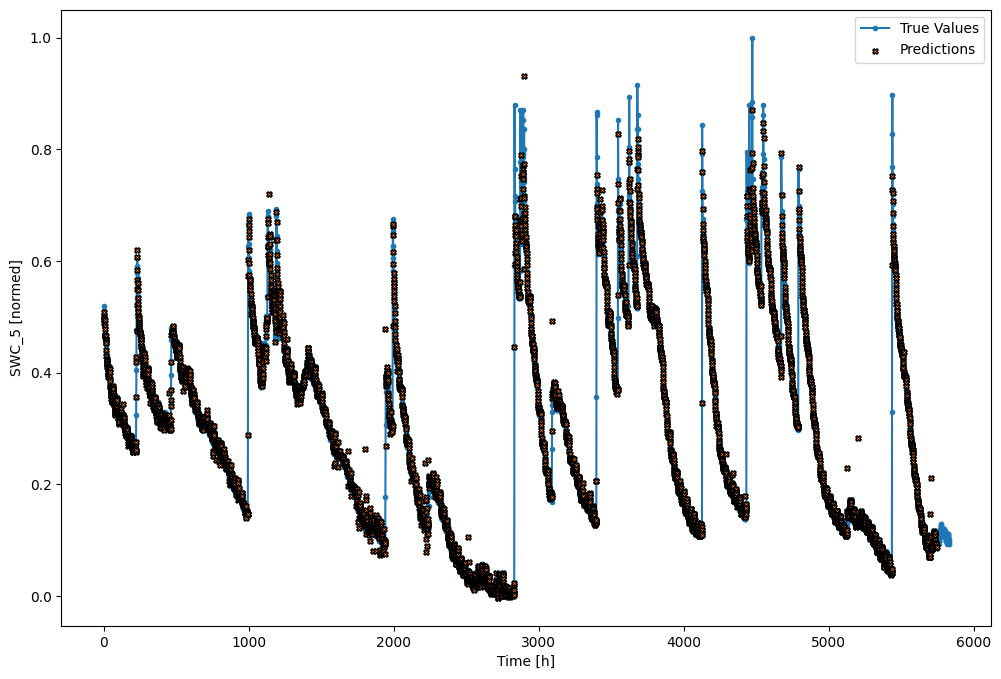

## 10 cm

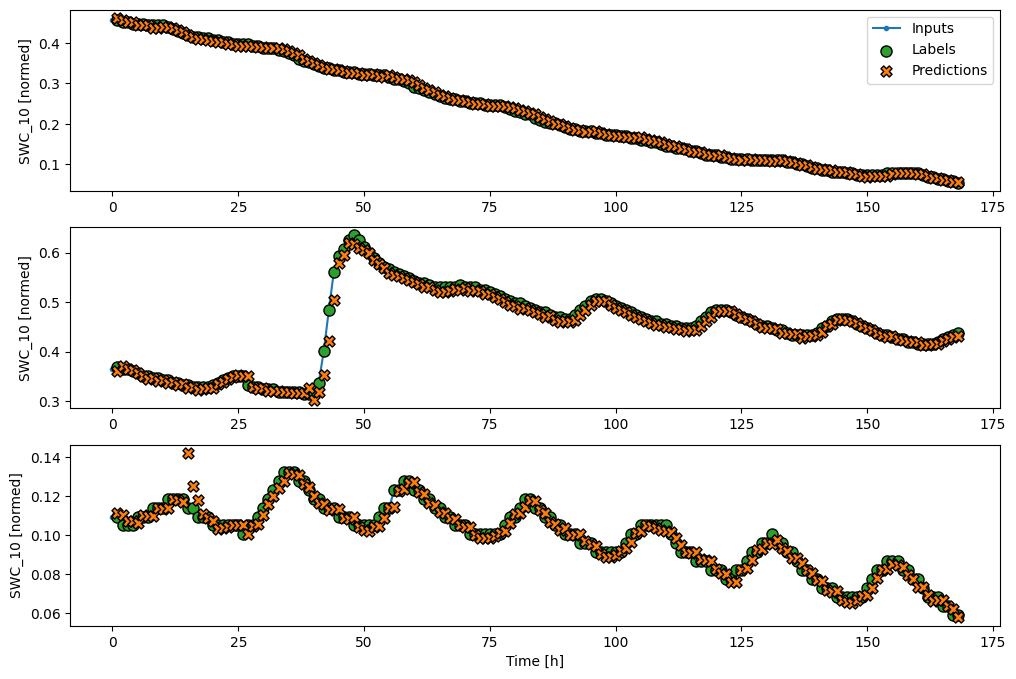

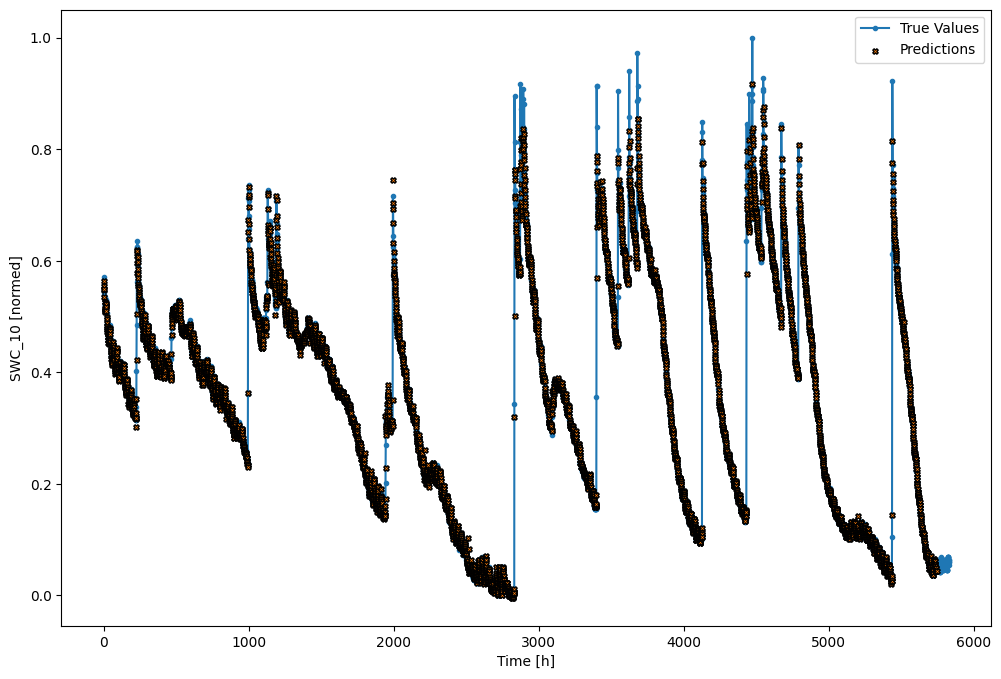

## 20 cm

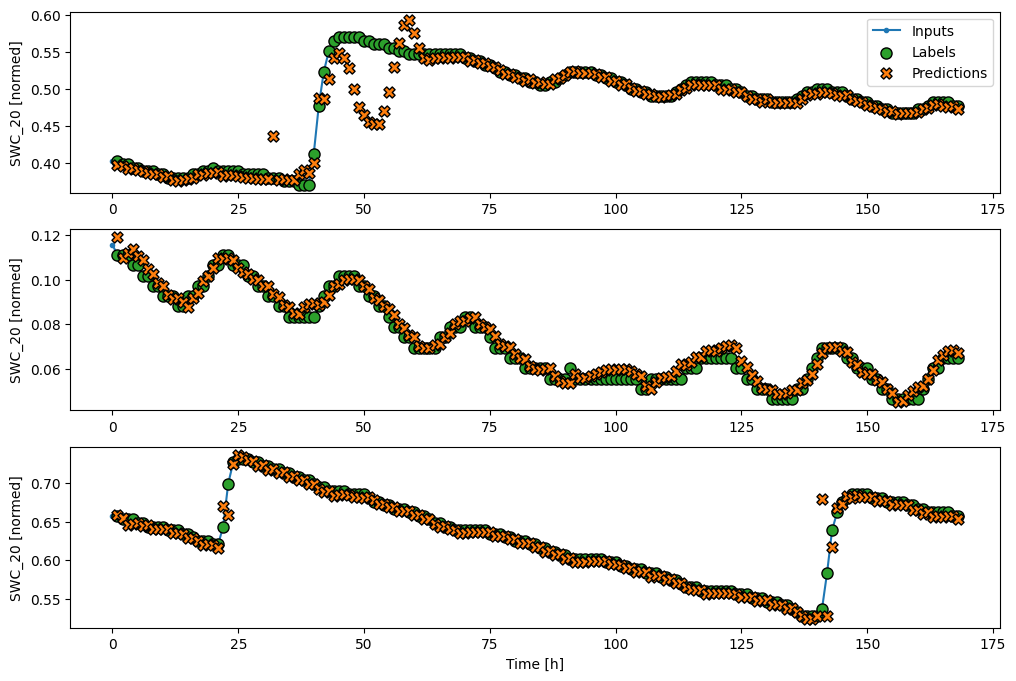

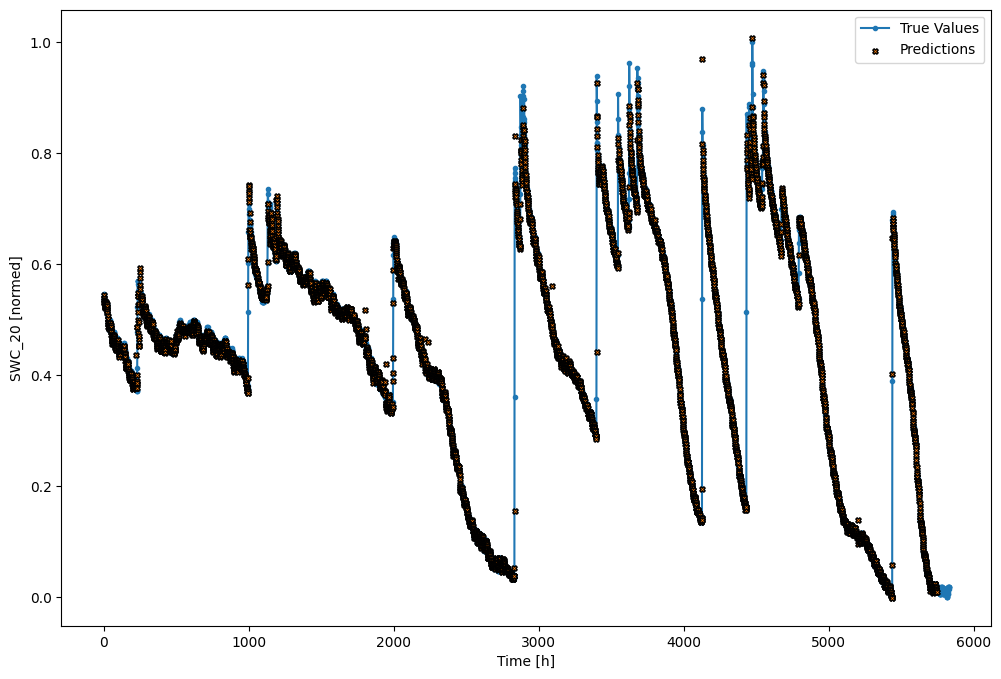

## 50 cm

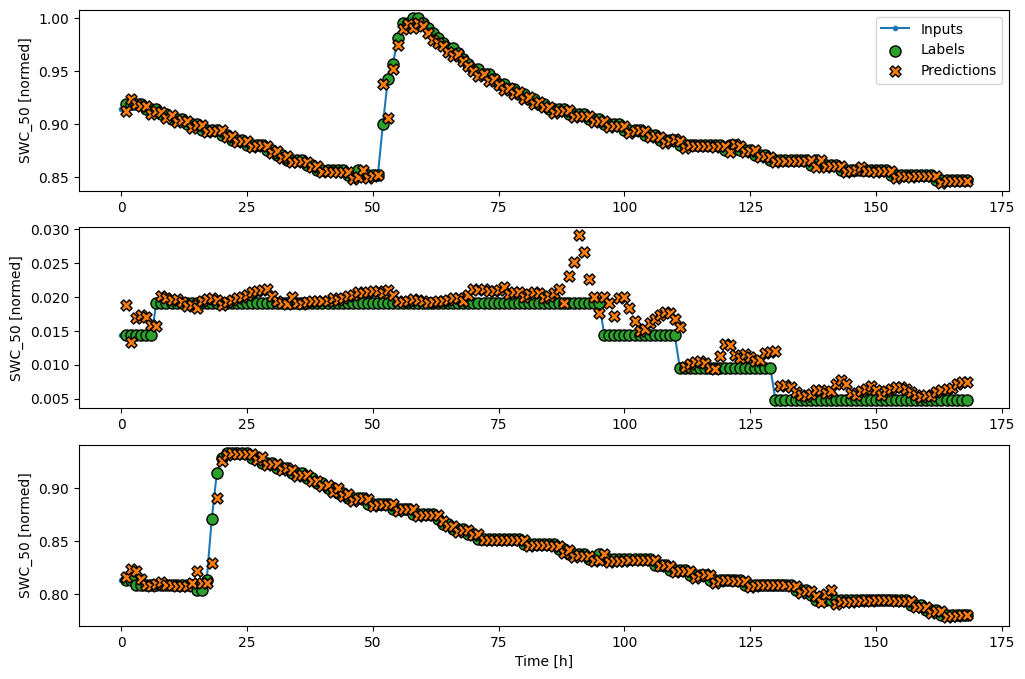

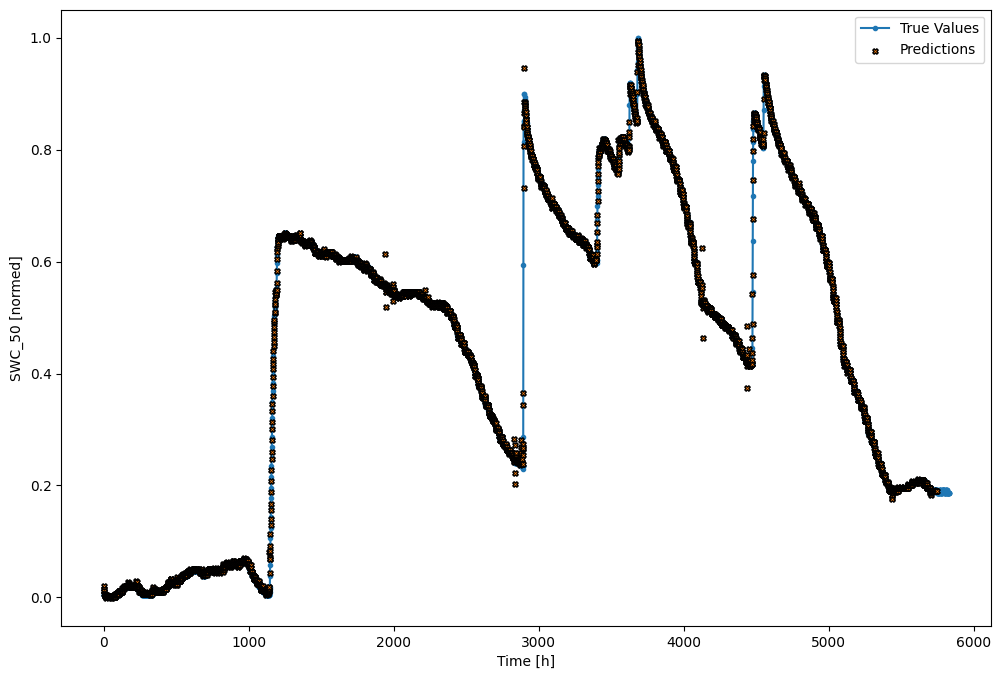